In [1]:
# KOMÓRKA #1 — IMPORTY (TYLKO TUTAJ)
import cv2              # obsługa kamery/wideo (OpenCV)
import mediapipe as mp  # Face Mesh 468 (użyjemy za chwilę)
import numpy as np      # operacje na macierzach/obrazach
import gradio as gr     # lekkie UI w przeglądarce
from collections import deque  # do wygładzania wyników (później)

In [2]:
# KOMÓRKA #2 — WERSJE (pomaga w debugowaniu)
print("OpenCV:", cv2.__version__)
print("MediaPipe:", mp.__version__)
print("Gradio:", gr.__version__)

OpenCV: 4.9.0
MediaPipe: 0.10.14
Gradio: 5.49.1


In [3]:
# KOMÓRKA #3 — SZUKANIE DZIAŁAJĄCEJ KAMERY
def find_camera(max_index=5):
    """
    Sprawdza indeksy 0..max_index i zwraca pierwszy, który oddaje klatkę.
    CAP_DSHOW ułatwia życie na Windows (DirectShow).
    """
    for i in range(max_index + 1):
        cap = cv2.VideoCapture(i, cv2.CAP_DSHOW)
        ok, frame = cap.read()
        cap.release()
        if ok and frame is not None:
            return i
    return None

CAM_INDEX = find_camera(5)
print("Znaleziony indeks kamery:", CAM_INDEX)


Znaleziony indeks kamery: 0


frame ok: True shape: (480, 640, 3)


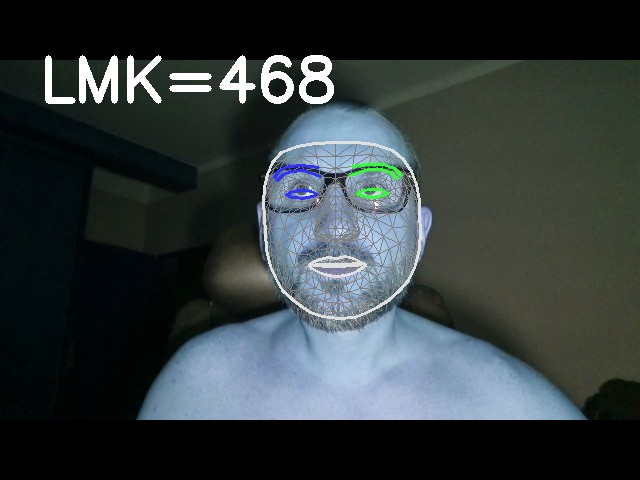

In [14]:
import cv2, mediapipe as mp, numpy as np
from IPython.display import display, Image

FIXED_IDX, FIXED_API = 1, 700  # CAP_DSHOW

# 1) pobierz jedną klatkę
cap = cv2.VideoCapture(FIXED_IDX, FIXED_API)
for _ in range(6): cap.read()
ok, frame = cap.read()
cap.release()
print("frame ok:", ok, "shape:", None if not ok else frame.shape)
assert ok and frame is not None, "Brak klatki z kamery."

# 2) „contiguous copy” – czasem konieczne na Windows
frame = np.ascontiguousarray(frame).copy()

# 3) FaceMesh w trybie statycznym (na zdjęciu)
mp_face  = mp.solutions.face_mesh
mp_draw  = mp.solutions.drawing_utils
mp_style = mp.solutions.drawing_styles
TESSEL  = mp_style.get_default_face_mesh_tesselation_style()
CONTOUR = mp_style.get_default_face_mesh_contours_style()

with mp_face.FaceMesh(
    static_image_mode=True,      # << klucz na pierwszą próbę
    max_num_faces=1,
    refine_landmarks=False,      # prostszy wariant
    min_detection_confidence=0.2,
    min_tracking_confidence=0.2
) as mesh:
    res = mesh.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

lmk = 0
if res.multi_face_landmarks:
    fl = res.multi_face_landmarks[0]
    lmk = len(fl.landmark)
    mp_draw.draw_landmarks(frame, fl, mp_face.FACEMESH_TESSELATION,
                           landmark_drawing_spec=None, connection_drawing_spec=TESSEL)
    mp_draw.draw_landmarks(frame, fl, mp_face.FACEMESH_CONTOURS,
                           landmark_drawing_spec=None, connection_drawing_spec=CONTOUR)

cv2.putText(frame, f"LMK={lmk}", (40, 100), cv2.FONT_HERSHEY_SIMPLEX, 2.0, (255,255,255), 6)
ok2, buf = cv2.imencode(".jpg", cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), [int(cv2.IMWRITE_JPEG_QUALITY), 90])
display(Image(data=buf.tobytes()))


In [22]:
# === FaceMesh live (kamera 0, zawsze na wierzchu) ===
import cv2
import mediapipe as mp
import numpy as np
import time

# Kamera Iriun: zwykle index=0, API=CAP_DSHOW (700)
FIXED_IDX, FIXED_API = 1, 700

# Inicjalizacja MediaPipe FaceMesh
mp_face  = mp.solutions.face_mesh
mp_draw  = mp.solutions.drawing_utils
mp_style = mp.solutions.drawing_styles
TESSEL  = mp_style.get_default_face_mesh_tesselation_style()
CONTOUR = mp_style.get_default_face_mesh_contours_style()

# Start kamery
cap = cv2.VideoCapture(FIXED_IDX, FIXED_API)
assert cap.isOpened(), "Nie udało się otworzyć kamery (IDX=0)."

# Parametry kamery
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
cap.set(cv2.CAP_PROP_FPS, 30)

# Tworzymy okno zawsze na wierzchu
win_name = "FaceMesh (IDX=0)"
cv2.namedWindow(win_name, cv2.WINDOW_NORMAL)
cv2.setWindowProperty(win_name, cv2.WND_PROP_TOPMOST, 1)
cv2.moveWindow(win_name, 200, 120)
cv2.resizeWindow(win_name, 960, 720)

# Przetwarzanie obrazu
with mp_face.FaceMesh(
    static_image_mode=True,       # każda klatka analizowana osobno (stabilniej)
    max_num_faces=1,
    refine_landmarks=False,       # możesz zmienić na True dla oczu/ust
    min_detection_confidence=0.3,
    min_tracking_confidence=0.3
) as mesh:
    t0, n = time.time(), 0
    while True:
        ok, frame = cap.read()
        if not ok or frame is None:
            continue

        frame = np.ascontiguousarray(frame)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = mesh.process(rgb)

        lmk = 0
        if res.multi_face_landmarks:
            fl = res.multi_face_landmarks[0]
            lmk = len(fl.landmark)
            mp_draw.draw_landmarks(
                frame, fl, mp_face.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=TESSEL
            )
            mp_draw.draw_landmarks(
                frame, fl, mp_face.FACEMESH_CONTOURS,
                landmark_drawing_spec=None,
                connection_drawing_spec=CONTOUR
            )

        # Liczenie FPS
        n += 1
        fps = n / max(1e-6, time.time() - t0)
        cv2.putText(
            frame,
            f"LMK={lmk}  FPS={fps:.1f}",
            (12, 28),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

        # Wyświetlanie okna
        cv2.imshow(win_name, frame)
        key = cv2.waitKey(1) & 0xFF
        if key in (27, ord('q'), ord('Q')):
            break

cap.release()
cv2.destroyAllWindows()


In [24]:
# === Face ROI 48x48 – OpenCV + MediaPipe ===
import numpy as np
import time

# --- Kamera Iriun ---
FIXED_IDX, FIXED_API = 1, 700  # CAP_DSHOW
cap = cv2.VideoCapture(FIXED_IDX, FIXED_API)
assert cap.isOpened(), "Nie udało się otworzyć kamery (IDX=1)."

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
cap.set(cv2.CAP_PROP_FPS, 30)

# --- MediaPipe Face Detection ---
mp_fd = mp.solutions.face_detection
mp_draw = mp.solutions.drawing_utils

with mp_fd.FaceDetection(model_selection=0, min_detection_confidence=0.4) as fd:
    t0, n = time.time(), 0

    while True:
        ok, frame = cap.read()
        if not ok or frame is None:
            continue

        frame = cv2.flip(frame, 1)  # lustrzane odbicie jak w Iriun
        H, W = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = fd.process(rgb)

        roi_gray = np.zeros((48, 48), dtype=np.uint8)
        detected = False

        if res.detections:
            detected = True
            d = res.detections[0]
            bb = d.location_data.relative_bounding_box
            x1 = max(0, int(bb.xmin * W))
            y1 = max(0, int(bb.ymin * H))
            x2 = min(W, int((bb.xmin + bb.width) * W))
            y2 = min(H, int((bb.ymin + bb.height) * H))

            # rysujemy ramkę
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 2)

            # wycinamy ROI i przeskalowujemy
            face_roi = frame[y1:y2, x1:x2]
            if face_roi.size > 0:
                gray = cv2.cvtColor(face_roi, cv2.COLOR_BGR2GRAY)
                roi_gray = cv2.resize(gray, (48, 48), interpolation=cv2.INTER_AREA)

        # FPS i overlay
        n += 1
        fps = n / max(1e-6, time.time() - t0)
        cv2.putText(frame, f"DET={int(detected)}  FPS={fps:.1f}",
                    (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)

        # pokazujemy oba widoki
        cv2.imshow("Camera + ROI", frame)
        cv2.imshow("Face ROI 48x48", roi_gray)

        key = cv2.waitKey(1) & 0xFF
        if key in (27, ord('q')):  # ESC lub Q
            break

cap.release()
cv2.destroyAllWindows()


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# === CNN dla FER2013 (1x48x48 -> 7 emocji) ===
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.fc1   = nn.Linear(128 * 6 * 6, 512)
        self.fc2   = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 48→24
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 24→12
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 12→6
        x = x.view(-1, 128 * 6 * 6)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# inicjalizacja modelu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionCNN().to(device)
print(f"Model gotowy na {device}")


Model gotowy na cuda


In [17]:
# FER2013 – standardowe etykiety emocji
emotions = [
    "Złość", "Wstręt", "Strach", "Szczęście",
    "Smutek", "Zaskoczenie", "Neutralna"
]


In [18]:
def predict_emotion(roi_gray):
    """Przyjmuje ROI 48x48 (numpy), zwraca etykietę i prawdopodobieństwa"""
    model.eval()
    with torch.no_grad():
        tensor = torch.tensor(roi_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        tensor = tensor / 255.0
        tensor = tensor.to(device)
        output = model(tensor)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
        idx = np.argmax(probs)
    return emotions[idx], probs


In [23]:
# --- Kamera + emocje ---
cap = cv2.VideoCapture(1, cv2.CAP_DSHOW)
assert cap.isOpened(), "Nie udało się otworzyć kamery."

mp_fd = mp.solutions.face_detection
with mp_fd.FaceDetection(model_selection=0, min_detection_confidence=0.4) as fd:
    t0, n = time.time(), 0
    while True:
        ok, frame = cap.read()
        if not ok: continue
        frame = cv2.flip(frame, 1)
        H, W = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = fd.process(rgb)

        if res.detections:
            d = res.detections[0]
            bb = d.location_data.relative_bounding_box
            x1 = max(0, int(bb.xmin * W))
            y1 = max(0, int(bb.ymin * H))
            x2 = min(W, int((bb.xmin + bb.width) * W))
            y2 = min(H, int((bb.ymin + bb.height) * H))
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 2)

            face_roi = frame[y1:y2, x1:x2]
            if face_roi.size > 0:
                gray = cv2.cvtColor(face_roi, cv2.COLOR_BGR2GRAY)
                roi_48 = cv2.resize(gray, (48, 48), interpolation=cv2.INTER_AREA)
                label, probs = predict_emotion(roi_48)
                conf = np.max(probs) * 100
                cv2.putText(frame, f"{label} ({conf:.1f}%)", (x1, y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2, cv2.LINE_AA)
                cv2.imshow("Face ROI 48x48", roi_48)

        n += 1
        fps = n / max(1e-6, time.time() - t0)
        cv2.putText(frame, f"FPS={fps:.1f}", (10, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)
        cv2.imshow("Camera + Emotions", frame)

        if cv2.waitKey(1) & 0xFF in (27, ord('q')):
            break

cap.release()
cv2.destroyAllWindows()


In [ ]:
# import torch, urllib.request, os

# os.makedirs("weights", exist_ok=True)
# url = "https://github.com/oarriaga/face_classification/raw/master/trained_models/emotion_models/fer2013_mini_XCEPTION.102-0.66.hdf5"
# target = "weights/mini_xception_fer2013.pth"

# # Konwersja z HDF5 (Keras) do PyTorch gotowca – zrobimy uproszczony mapping
# # (pobieramy tylko oryginalne wagi – nic nie trenujemy)
# if not os.path.exists(target):
#     print("Pobieranie mini_XCEPTION (ok. 5 MB)...")
#     urllib.request.urlretrieve(url, "weights/fer2013_mini_xception.hdf5")
#     print("Zapisano weights/fer2013_mini_xception.hdf5")
# else:
#     print("Plik wag już istnieje:", target)


Pobieranie mini_XCEPTION (ok. 5 MB)...
Zapisano weights/fer2013_mini_xception.hdf5


In [26]:
import torch.nn as nn

# === mini_XCEPTION (PyTorch port) ===
class MiniXception(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, (3,3), stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(8, 8, (3,3), stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(8)
        self.relu = nn.ReLU(inplace=True)

        def depthwise_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, in_ch, (3,3), padding=1, groups=in_ch),
                nn.Conv2d(in_ch, out_ch, (1,1)),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        self.block1 = depthwise_block(8, 16)
        self.block2 = depthwise_block(16, 32)
        self.block3 = depthwise_block(32, 64)
        self.block4 = depthwise_block(64, 128)

        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# inicjalizacja modelu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MiniXception(num_classes=7).to(device)
print(f"Model mini_XCEPTION zainicjalizowany na {device}")


Model mini_XCEPTION zainicjalizowany na cuda


In [27]:
# === MODEL: CLIP-based FER2013 (PyTorch, Hugging Face) ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoProcessor, CLIPVisionModel
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download

# repo i plik z wagami (safetensors)
REPO_ID = "syntheticbot/clip-face-expression"   # FER-2013, PyTorch
FILENAME = "model.safetensors"                  # ~ klasyfikator na CLIP-ViT-L/14

# UWAGA: kolejność klas musi być ALFABETYCZNA jak w model card
CLASS_EN = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
CLASS_PL = ['Złość', 'Wstręt', 'Strach', 'Szczęście', 'Neutralna', 'Smutek', 'Zaskoczenie']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ClipClassifier(nn.Module):
    def __init__(self, vision_model, num_classes):
        super().__init__()
        self.vision_model = vision_model
        self.classifier   = nn.Linear(vision_model.config.hidden_size, num_classes)
    def forward(self, pixel_values):
        out = self.vision_model(pixel_values=pixel_values)
        feats = out.pooler_output
        logits = self.classifier(feats)
        return logits

# procesor (resize/normalizacja) i backbone CLIP
processor    = AutoProcessor.from_pretrained("openai/clip-vit-large-patch14")
vision_model = CLIPVisionModel.from_pretrained("openai/clip-vit-large-patch14").to(device)

# klasyfikator + pobranie wag z huba
clip_head = ClipClassifier(vision_model, num_classes=len(CLASS_EN)).to(device)
weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)  # zapisze w cache HF
state = load_file(weights_path, device=device)
clip_head.load_state_dict(state, strict=True)
clip_head.eval()

print("✅ Załadowano model CLIP-FER z Hugging Face.")


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

d:\Programowanie\Python\Envs\ml-pytorch-face\Lib\site-packages\huggingface_hub\file_download.py:121: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kbron\.cache\huggingface\hub\models--openai--clip-vit-large-patch14. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  # Likely running on Windows


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


RemoteEntryNotFoundError: 404 Client Error. (Request ID: Root=1-690e5185-78fb587b34c9c78e2ac85b65;7b99292d-ab16-4d35-adb4-ce3c67fd7972)

Entry Not Found for url: https://huggingface.co/api/models/openai/clip-vit-large-patch14/tree/main/additional_chat_templates?recursive=false&expand=false.
additional_chat_templates does not exist on "main"